In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('gsearch_jobs.csv')

# First look at the data
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (61953, 27)

Columns: ['Unnamed: 0', 'index', 'title', 'company_name', 'location', 'via', 'description', 'extensions', 'job_id', 'thumbnail', 'posted_at', 'schedule_type', 'work_from_home', 'salary', 'search_term', 'date_time', 'search_location', 'commute_time', 'salary_pay', 'salary_rate', 'salary_avg', 'salary_min', 'salary_max', 'salary_hourly', 'salary_yearly', 'salary_standardized', 'description_tokens']

First 3 rows:


,Unnamed: 0,index,title,company_name,location,via,description,extensions,job_id,thumbnail,...,commute_time,salary_pay,salary_rate,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens
0,0,0,Data Analyst,Meta,Anywhere,via LinkedIn,In the intersection of compliance and analytic...,"['15 hours ago', '101K–143K a year', 'Work fro...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,101K–143K,a year,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"['tableau', 'r', 'python', 'sql']"
1,1,1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,"['12 hours ago', 'Full-time', 'Health insurance']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
2,2,2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,"['18 hours ago', 'Full-time']",eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql']


In [2]:
# Check for missing values and data types
print("Missing values per column:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Missing values per column:
Unnamed: 0                 0
index                      0
title                      0
company_name               0
location                  37
via                        9
description                0
extensions                 0
job_id                     0
thumbnail              23759
posted_at                190
schedule_type            246
work_from_home         33973
salary                 51865
search_term                0
date_time                  0
search_location            0
commute_time           61953
salary_pay             51865
salary_rate            51865
salary_avg             51865
salary_min             52441
salary_max             52441
salary_hourly          56053
salary_yearly          57884
salary_standardized    51865
description_tokens         0
dtype: int64

Data types:
Unnamed: 0               int64
index                    int64
title                      str
company_name               str
location                   str
via      

C:\Users\niloy\AppData\Local\Temp\ipykernel_24144\279888779.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_titles.values, y=top_titles.index, palette='Blues_r')


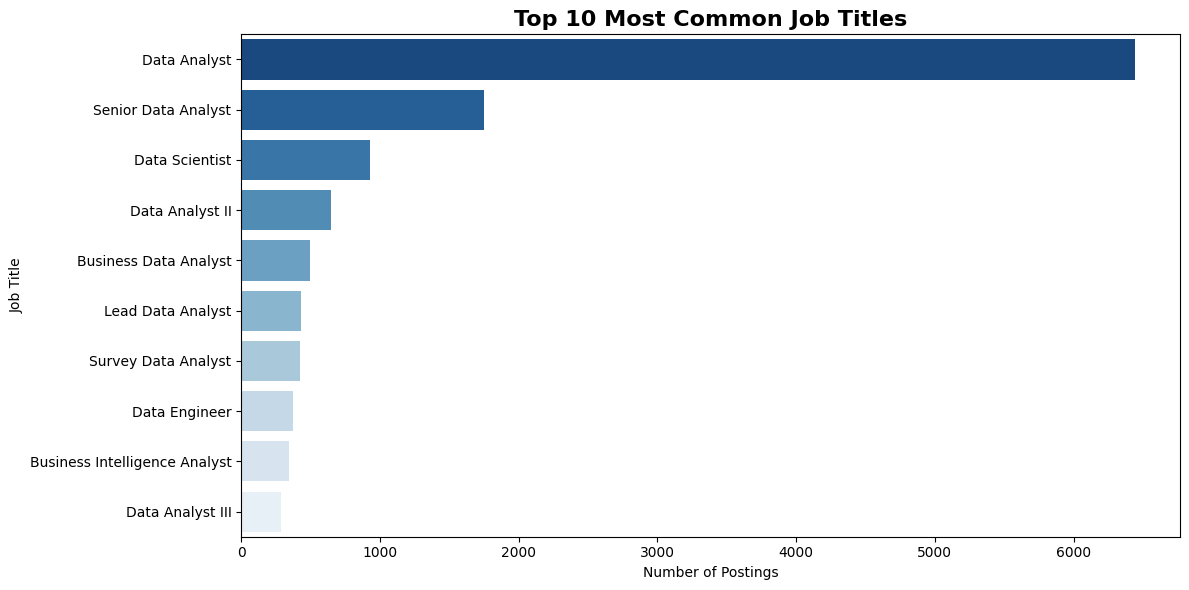

In [3]:
# --- CHART 1: Top 10 Job Titles ---
plt.figure(figsize=(12, 6))

top_titles = df['title'].value_counts().head(10)

sns.barplot(x=top_titles.values, y=top_titles.index, palette='Blues_r')
plt.title('Top 10 Most Common Job Titles', fontsize=16, fontweight='bold')
plt.xlabel('Number of Postings')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

C:\Users\niloy\AppData\Local\Temp\ipykernel_24144\4084363580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.values, y=top_companies.index, palette='Greens_r')


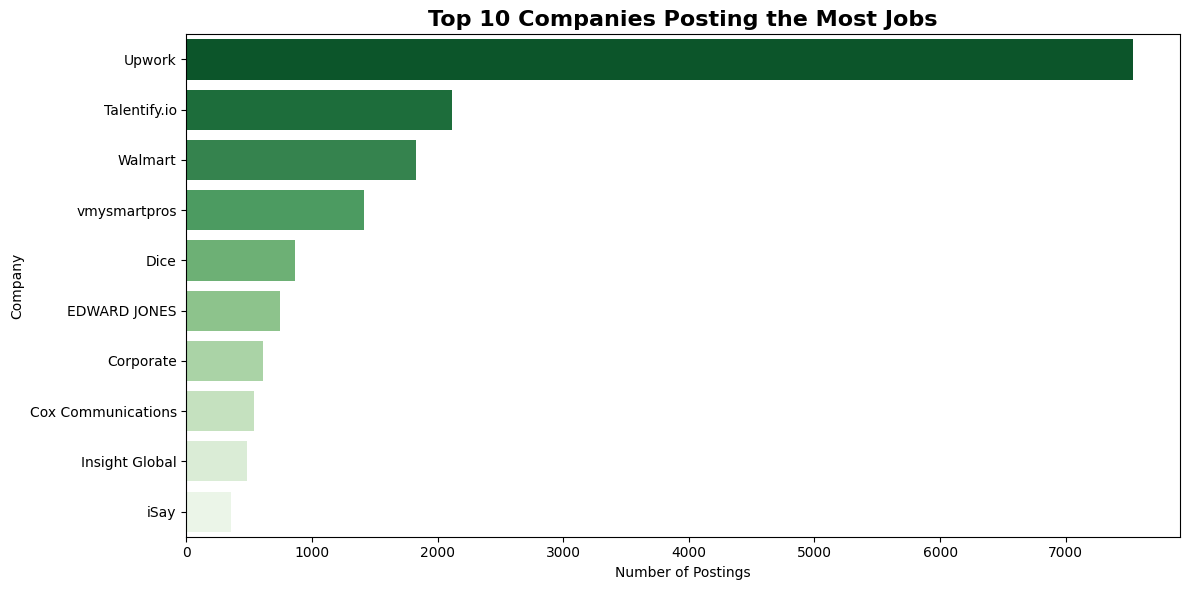

In [4]:
# --- CHART 2: Top 10 Hiring Companies ---
plt.figure(figsize=(12, 6))

top_companies = df['company_name'].value_counts().head(10)

sns.barplot(x=top_companies.values, y=top_companies.index, palette='Greens_r')
plt.title('Top 10 Companies Posting the Most Jobs', fontsize=16, fontweight='bold')
plt.xlabel('Number of Postings')
plt.ylabel('Company')
plt.tight_layout()
plt.show()

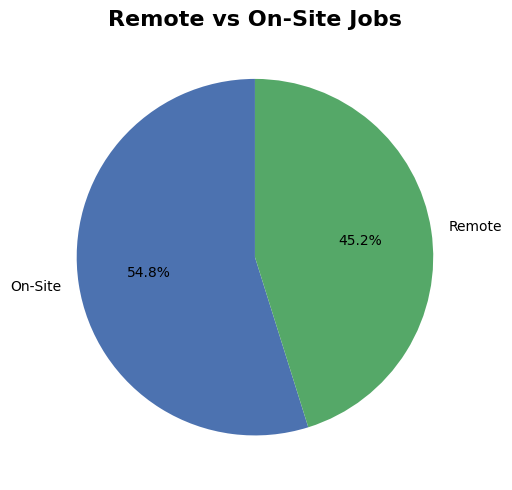

In [5]:
# --- CHART 3: Work From Home vs On-Site ---
plt.figure(figsize=(8, 5))

wfh_counts = df['work_from_home'].fillna(False).value_counts()
labels = ['On-Site', 'Remote']
colors = ['#4C72B0', '#55A868']

plt.pie(wfh_counts.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Remote vs On-Site Jobs', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\niloy\AppData\Local\Temp\ipykernel_24144\322389371.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Skill', data=top_skills, palette='Oranges_r')


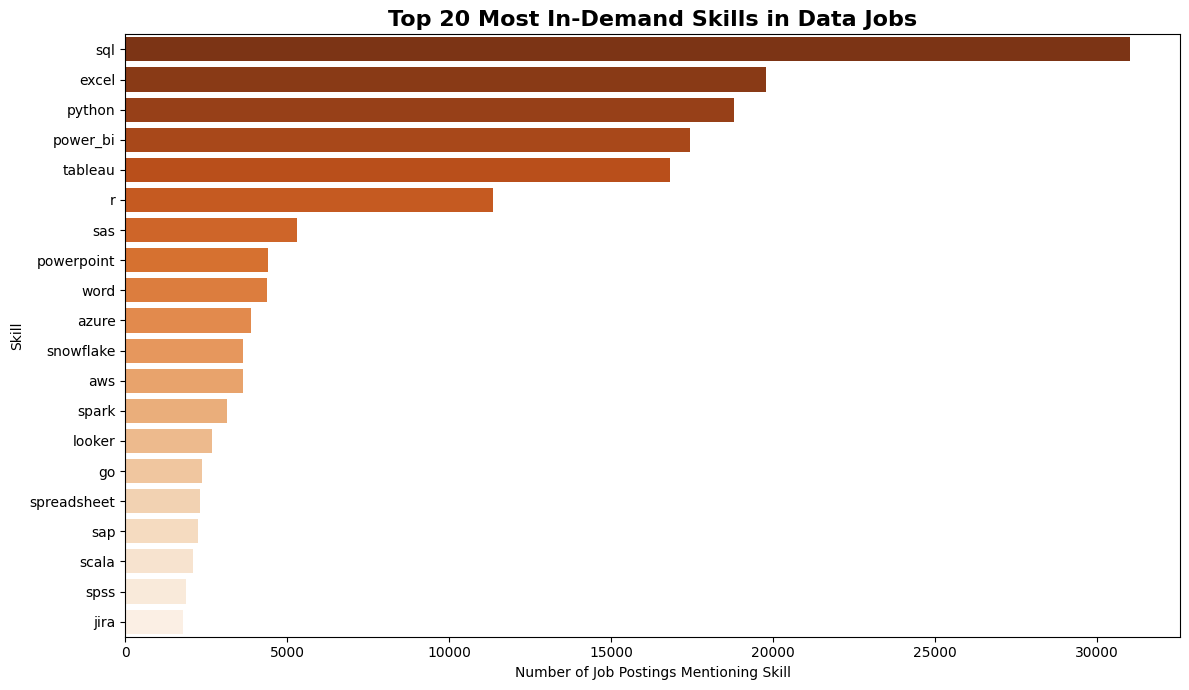

In [6]:
# --- CHART 4: Top 20 Most In-Demand Skills ---
import ast

# Convert string representation of lists to actual lists
skills_series = df['description_tokens'].dropna().apply(ast.literal_eval)

# Flatten all skills into one list and count
from collections import Counter
all_skills = [skill for sublist in skills_series for skill in sublist]
skill_counts = Counter(all_skills)

# Get top 20
top_skills = pd.DataFrame(skill_counts.most_common(20), columns=['Skill', 'Count'])

plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='Skill', data=top_skills, palette='Oranges_r')
plt.title('Top 20 Most In-Demand Skills in Data Jobs', fontsize=16, fontweight='bold')
plt.xlabel('Number of Job Postings Mentioning Skill')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()

C:\Users\niloy\AppData\Local\Temp\ipykernel_24144\2091851619.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=schedule_counts.index, y=schedule_counts.values, palette='Purples_r')


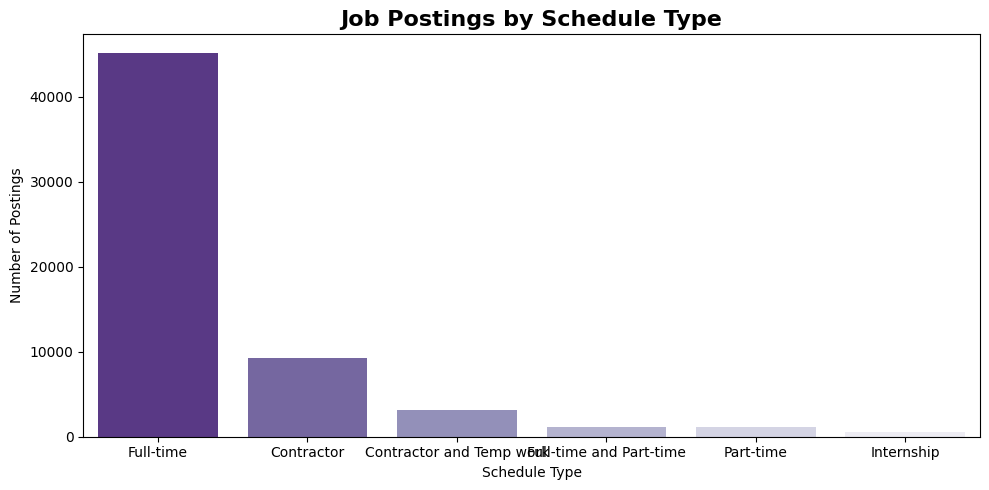

In [7]:
# --- CHART 5: Job Schedule Types ---
plt.figure(figsize=(10, 5))

schedule_counts = df['schedule_type'].value_counts().head(6)

sns.barplot(x=schedule_counts.index, y=schedule_counts.values, palette='Purples_r')
plt.title('Job Postings by Schedule Type', fontsize=16, fontweight='bold')
plt.xlabel('Schedule Type')
plt.ylabel('Number of Postings')
plt.tight_layout()
plt.show()

# Data Job Market Analysis — Key Findings

## Dataset
- **61,953 job postings** analyzed from Google Search job data
- **27 features** including title, company, location, skills, and schedule type

## Key Findings

### 1. Most In-Demand Job Titles
"Data Analyst" is the most posted role with over 6,000 postings — nearly double "Senior Data Analyst" in second place.

### 2. Top Hiring Companies
Upwork leads all companies, suggesting strong freelance/contract demand. Walmart's presence highlights data roles expanding beyond tech companies.

### 3. Remote vs On-Site
The market is nearly split — 54.8% on-site vs 45.2% remote — showing remote data work remains widely available.

### 4. Most In-Demand Skills
**SQL** is the single most requested skill, appearing in nearly 30,000 postings. The top 5 skills are:
1. SQL
2. Excel
3. Python
4. Power BI
5. Tableau

### 5. Schedule Types
Full-time roles dominate at ~45,000 postings. Contract roles are a strong second, reflecting the freelance demand seen in company data.

## Tools Used
Python · Pandas · Matplotlib · Seaborn · Jupyter Notebook